In [1]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import os
from load_data import get_dataset
from pipeline import get_preprocessor
from print_metric import print_results
import joblib
os.makedirs("models", exist_ok=True)

In [2]:
X_train, X_test, y_train, y_test = get_dataset()

In [3]:
preprocessor = get_preprocessor()

In [4]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [5]:
cv_score = cross_val_score(pipe, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")

In [6]:
cv_score

array([-2366.07467993, -2061.30431169, -2393.54482402, -2622.74667299,
       -2502.98603976])

In [7]:
cv_score.mean()

np.float64(-2389.3313056783945)

In [8]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...), ('column_transformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...t 0x11befd590>
,"inverse_func inverse_func: callable, default=NoneThe callable to use fo

In [9]:
y_pred = pipe.predict(X_test)

In [10]:
residuals = y_test - y_pred

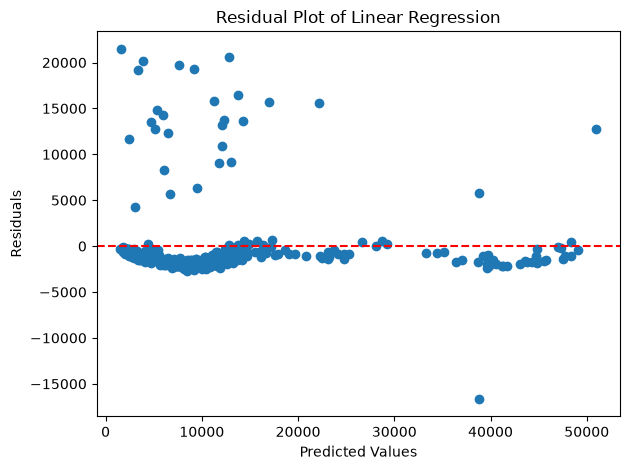

In [11]:
plt.title("Residual Plot of Linear Regression")
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.tight_layout()
plt.savefig("images/residual_plot_linear_regression.png", dpi=1200)
plt.show()

In [12]:
pipe.named_steps["model"].coef_

array([ 3740.27456071,   117.96616573,   588.70248033,  5526.67925092,
        4877.98209096,   236.27852993,  -236.27852993, -1069.68366916,
        1069.68366916,   624.86024427,   209.70547   ,  -138.89320239,
        -695.67251187])

In [13]:
print("Training")
print_results(y_train, pipe.predict(X_train))
print("\n")
print("Testing")
print_results(y_test, pipe.predict(X_test))

Training
R2 Score 0.8670173618722862
MAE 2354.226485826525
MSE 19294503.337042466
RMSE 4392.550891798804


Testing
R2 Score 0.8689986612125593
MAE 2391.044421968229
MSE 19766941.31246071
RMSE 4446.002846654589


In [14]:
joblib.dump(pipe, "models/linear_regression_pipeline.pkl")
print("Model saved successfully")

Model saved successfully
